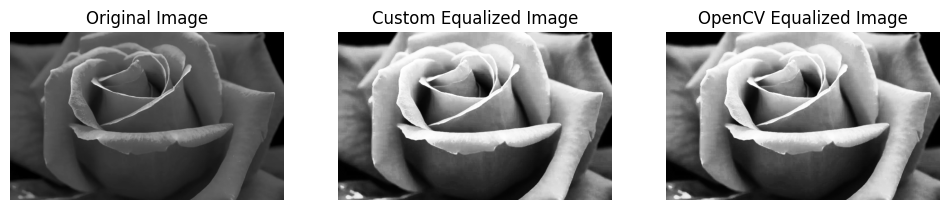

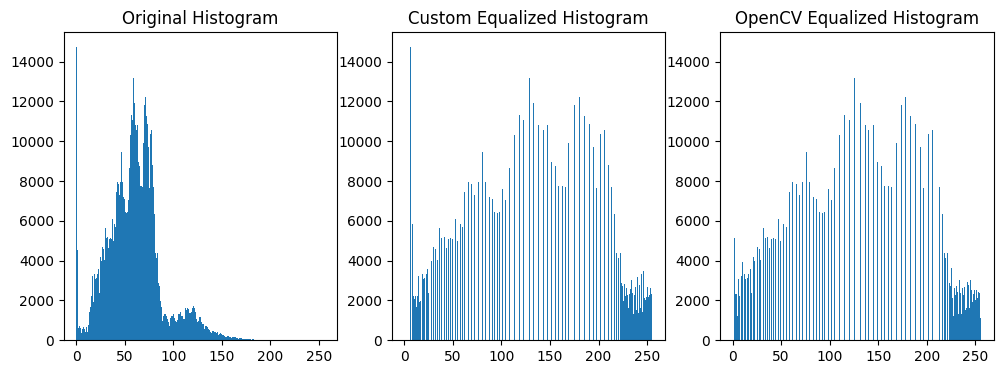

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread(r"C:\Users\lenovo\Downloads\rose.webp", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image not found")
    exit()

# Manual Histogram Equalization
values, counts = np.unique(image, return_counts=True)

total_pixels = image.size
pdf = counts / total_pixels
cdf = np.cumsum(pdf)

transform = np.floor(255 * cdf).astype(np.uint8)

equalized = np.zeros_like(image)

for i, v in enumerate(values):
    equalized[image == v] = transform[i]

# OpenCV Histogram Equalization
opencv = cv2.equalizeHist(image)

# Display images
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray')
plt.title("Custom Equalized Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(opencv, cmap='gray')
plt.title("OpenCV Equalized Image")
plt.axis("off")

plt.show()

# Display histograms
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(image.ravel(), bins=256, range=[0,256])
plt.title("Original Histogram")

plt.subplot(1,3,2)
plt.hist(equalized.ravel(), bins=256, range=[0,256])
plt.title("Custom Equalized Histogram")

plt.subplot(1,3,3)
plt.hist(opencv.ravel(), bins=256, range=[0,256])
plt.title("OpenCV Equalized Histogram")

plt.show()